In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

In [3]:
file_path = '/content/drive/MyDrive/Retail Analytics System/data/cleaned/clean_retail.csv'

df = pd.read_csv(file_path)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1


In [4]:
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Convert Customer ID to integer
df['Customer ID'] = df['Customer ID'].astype(int)

# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 779425 entries, 0 to 779424
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  int64         
 1   StockCode    779425 non-null  object        
 2   Description  779425 non-null  object        
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[ns]
 5   Price        779425 non-null  float64       
 6   Customer ID  779425 non-null  int64         
 7   Country      779425 non-null  object        
 8   Revenue      779425 non-null  float64       
 9   Year         779425 non-null  int64         
 10  Month        779425 non-null  int64         
 11  Day          779425 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(6), object(3)
memory usage: 71.4+ MB


In [5]:
# Create Snapshot Date (1 day after the last transaction)

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Last Transaction Date :", df['InvoiceDate'].max())
print("Snapshot Date         :", snapshot_date)

Last Transaction Date : 2011-12-09 12:50:00
Snapshot Date         : 2011-12-10 12:50:00


In [6]:
# Calculate RFM Metrics

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'Revenue': 'sum'
})

# Rename columns
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'Revenue': 'Monetary'
}, inplace=True)

# Display first 10 rows
rfm.head(10)

,Recency,Frequency,Monetary
Customer ID,,,
12346,326,12,77556.46
12347,2,8,4921.53
12348,75,5,2019.40
12349,19,4,4428.69
12350,310,1,334.40
12351,375,1,300.93
12352,36,10,2849.84
12353,204,2,406.76
12354,232,1,1079.40


In [7]:
# -------------------------------
# RFM Scoring (1–5)
# -------------------------------

# Recency (Lower = Better)
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5, 4, 3, 2, 1]
)

# Frequency (Higher = Better)
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
)

# Monetary (Higher = Better)
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1, 2, 3, 4, 5]
)

# Convert scores to integers
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

# Display first 10 rows
rfm.head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
Customer ID,,,,,,
12346,326,12,77556.46,2,5,5
12347,2,8,4921.53,5,4,5
12348,75,5,2019.40,3,4,4
12349,19,4,4428.69,5,3,5
12350,310,1,334.40,2,1,2
12351,375,1,300.93,2,1,2
12352,36,10,2849.84,4,5,4
12353,204,2,406.76,2,2,2
12354,232,1,1079.40,2,1,3


In [8]:
# Create Overall RFM Score

rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

rfm.head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
12346,326,12,77556.46,2,5,5,255
12347,2,8,4921.53,5,4,5,545
12348,75,5,2019.40,3,4,4,344
12349,19,4,4428.69,5,3,5,535
12350,310,1,334.40,2,1,2,212
12351,375,1,300.93,2,1,2,212
12352,36,10,2849.84,4,5,4,454
12353,204,2,406.76,2,2,2,222
12354,232,1,1079.40,2,1,3,213


In [9]:
# -----------------------------------
# Create Customer Segments
# -----------------------------------

def segment_customer(row):
    r = row['R_Score']
    f = row['F_Score']
    m = row['M_Score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'

    elif r >= 3 and f >= 4:
        return 'Loyal Customers'

    elif r >= 4 and f >= 2:
        return 'Potential Loyalists'

    elif r >= 4 and f <= 2:
        return 'New Customers'

    elif r == 3 and f == 3:
        return 'Promising'

    elif r == 3 and f <= 2:
        return 'Need Attention'

    elif r == 2 and f >= 3:
        return 'About to Sleep'

    elif r <= 2 and f >= 4:
        return 'At Risk'

    elif r == 1 and f == 5:
        return 'Cannot Lose Them'

    else:
        return 'Lost Customers'


rfm['Segment'] = rfm.apply(segment_customer, axis=1)

rfm.head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer ID,,,,,,,,
12346,326,12,77556.46,2,5,5,255,About to Sleep
12347,2,8,4921.53,5,4,5,545,Champions
12348,75,5,2019.40,3,4,4,344,Loyal Customers
12349,19,4,4428.69,5,3,5,535,Potential Loyalists
12350,310,1,334.40,2,1,2,212,Lost Customers
12351,375,1,300.93,2,1,2,212,Lost Customers
12352,36,10,2849.84,4,5,4,454,Champions
12353,204,2,406.76,2,2,2,222,Lost Customers
12354,232,1,1079.40,2,1,3,213,Lost Customers


In [10]:
# Count customers in each segment

segment_summary = (
    rfm['Segment']
    .value_counts()
    .reset_index()
)

segment_summary.columns = ['Segment', 'Customer_Count']

segment_summary

,Segment,Customer_Count
0,Lost Customers,1707
1,Champions,1297
2,Potential Loyalists,714
3,Loyal Customers,701
4,About to Sleep,551
5,Need Attention,385
6,Promising,266
7,New Customers,168
8,At Risk,89


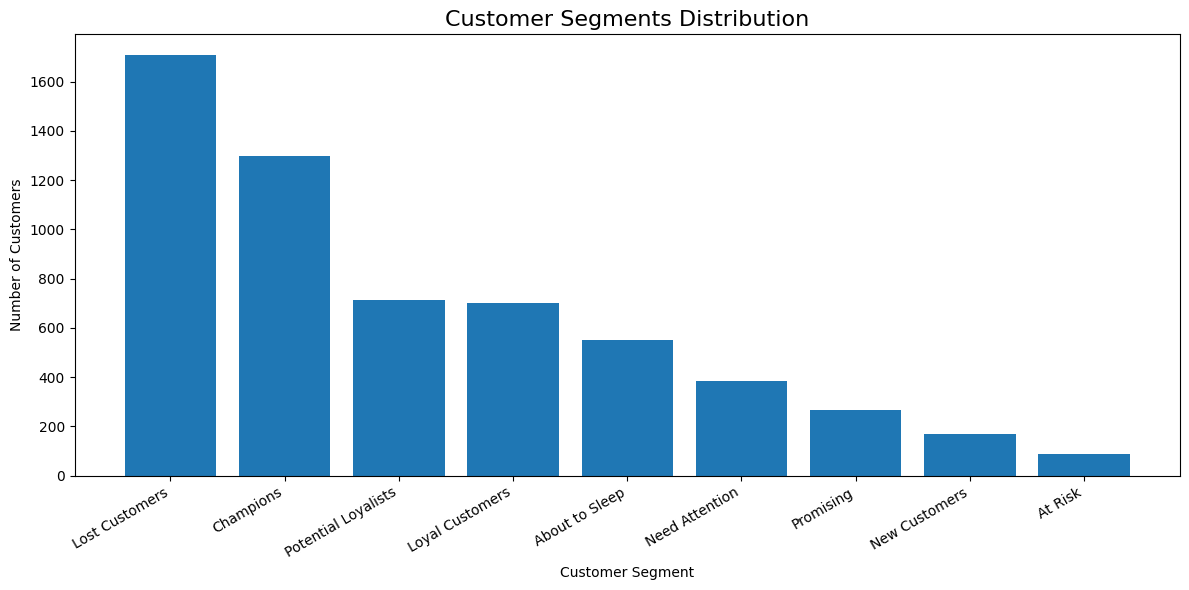

In [11]:
# -----------------------------------
# Customer Segment Distribution Chart
# -----------------------------------

plt.figure(figsize=(12,6))

segment_summary = segment_summary.sort_values(
    by='Customer_Count',
    ascending=False
)

plt.bar(
    segment_summary['Segment'],
    segment_summary['Customer_Count']
)

plt.title('Customer Segments Distribution', fontsize=16)
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')

plt.xticks(rotation=30, ha='right')

plt.tight_layout()

plt.show()

In [12]:
# Export RFM Analysis

output_path = "/content/drive/MyDrive/Retail Analytics System/data/cleaned/rfm_analysis.csv"

rfm.to_csv(output_path)

print("RFM Analysis exported successfully!")

RFM Analysis exported successfully!


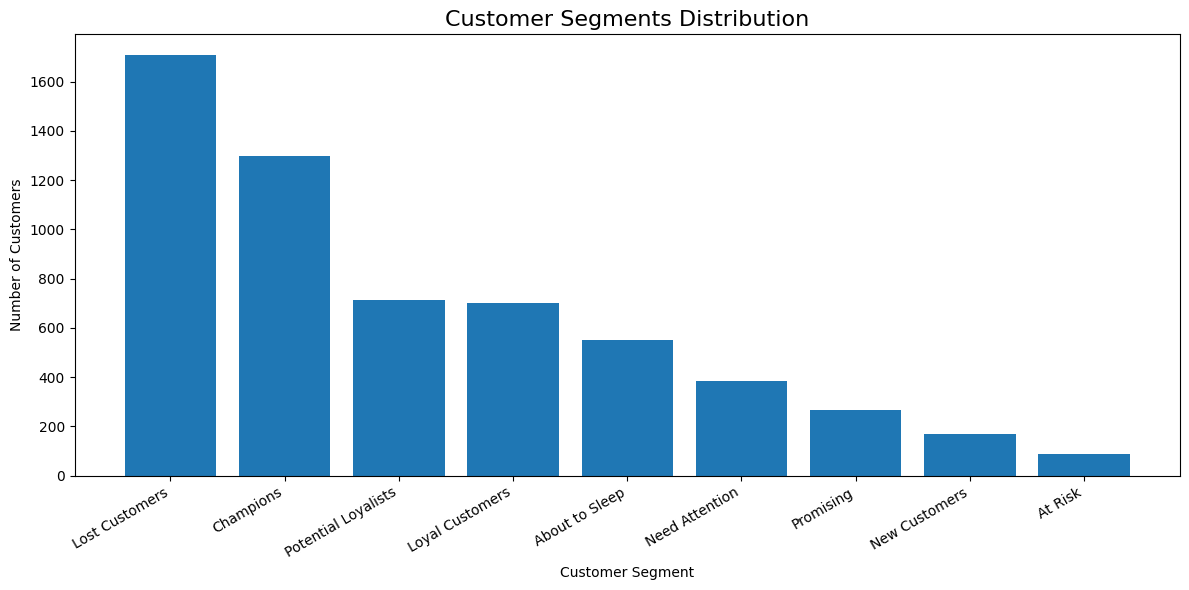

Chart saved successfully!


In [15]:
import os

# Save Customer Segment Distribution Chart

plt.figure(figsize=(12,6))

segment_summary = segment_summary.sort_values(
    by='Customer_Count',
    ascending=False
)

plt.bar(
    segment_summary['Segment'],
    segment_summary['Customer_Count']
)

plt.title('Customer Segments Distribution', fontsize=16)
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')

plt.xticks(rotation=30, ha='right')

plt.tight_layout()

chart_path = "/content/drive/MyDrive/Retail Analytics System/screenshots/customer_segments_distribution.png"

# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(chart_path), exist_ok=True)

plt.savefig(chart_path, dpi=300, bbox_inches='tight')

plt.show()

print("Chart saved successfully!")